In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df = pd.read_csv("01_numpy_ng.csv")
# DateTime을 한국 시간(KST)으로 변환
df['DateTime'] = pd.to_datetime(df['DateTime'])
df['DateTime'] = df['DateTime'].dt.tz_localize('UTC').dt.tz_convert('Asia/Seoul')
df.head(3)

,DateTime,vuser,Tests,Errors,Mean_Test_Time_(ms),Test_Time_Standard_Deviation_(ms),TPS,Mean_response_length,Response_bytes_per_second,Response_errors,Mean_time_to_resolve_host,Mean_time_to_establish_connection,Mean_time_to_first_byte
0,2025-02-28 16:11:21+09:00,10,17,0,1051.353,70.869,8.5,82.824,704.0,0,0,7.000,19.235
1,2025-02-28 16:11:23+09:00,20,45,0,995.489,56.031,22.5,83.111,1870.0,0,0,0.667,4.467
2,2025-02-28 16:11:25+09:00,20,42,0,1007.929,61.928,21.0,83.238,1748.0,0,0,0.571,4.381


In [37]:
print(df.head(3).to_csv(index=False))

DateTime,vuser,Tests,Errors,Mean_Test_Time_(ms),Test_Time_Standard_Deviation_(ms),TPS,Mean_response_length,Response_bytes_per_second,Response_errors,Mean_time_to_resolve_host,Mean_time_to_establish_connection,Mean_time_to_first_byte
2025-02-28 16:11:21+09:00,10,17,0,1051.353,70.869,8.5,82.824,704.0,0,0,7.0,19.235
2025-02-28 16:11:23+09:00,20,45,0,995.489,56.031,22.5,83.111,1870.0,0,0,0.667,4.467
2025-02-28 16:11:25+09:00,20,42,0,1007.929,61.928,21.0,83.238,1748.0,0,0,0.571,4.381



In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype                     
---  ------                             --------------  -----                     
 0   DateTime                           294 non-null    datetime64[ns, Asia/Seoul]
 1   vuser                              294 non-null    int64                     
 2   Tests                              294 non-null    int64                     
 3   Errors                             294 non-null    int64                     
 4   Mean_Test_Time_(ms)                294 non-null    float64                   
 5   Test_Time_Standard_Deviation_(ms)  294 non-null    float64                   
 6   TPS                                294 non-null    float64                   
 7   Mean_response_length               294 non-null    float64                   
 8   Response_bytes_per_second          294 non-null    float64  

In [39]:
df.describe()

,vuser,Tests,Errors,Mean_Test_Time_(ms),Test_Time_Standard_Deviation_(ms),TPS,Mean_response_length,Response_bytes_per_second,Response_errors,Mean_time_to_resolve_host,Mean_time_to_establish_connection,Mean_time_to_first_byte
count,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.0,294.0,294.000000,294.000000
mean,602.721088,756.500000,213.693878,1316.669670,127.956269,378.250000,81.900466,30892.221088,0.0,0.0,0.226316,310.819575
std,323.955961,319.962474,341.057983,355.752426,97.715612,159.981237,0.805188,12959.300055,0.0,0.0,0.522389,353.981740
min,10.000000,17.000000,0.000000,989.644000,54.110000,8.500000,81.043000,704.000000,0.0,0.0,-5.392000,-12.960000
25%,320.000000,554.000000,0.000000,1007.842250,65.828250,277.000000,81.185500,22515.125000,0.0,0.0,0.168000,5.721250
50%,628.000000,823.000000,0.000000,1159.581000,79.542500,411.500000,81.345000,33568.750000,0.0,0.0,0.189500,153.558500
75%,937.500000,984.000000,362.250000,1589.564000,156.644750,492.000000,82.802000,39961.625000,0.0,0.0,0.236000,556.132000
max,1000.000000,1756.000000,1647.000000,2209.334000,520.588000,878.000000,83.375000,71242.500000,0.0,0.0,7.000000,1215.450000


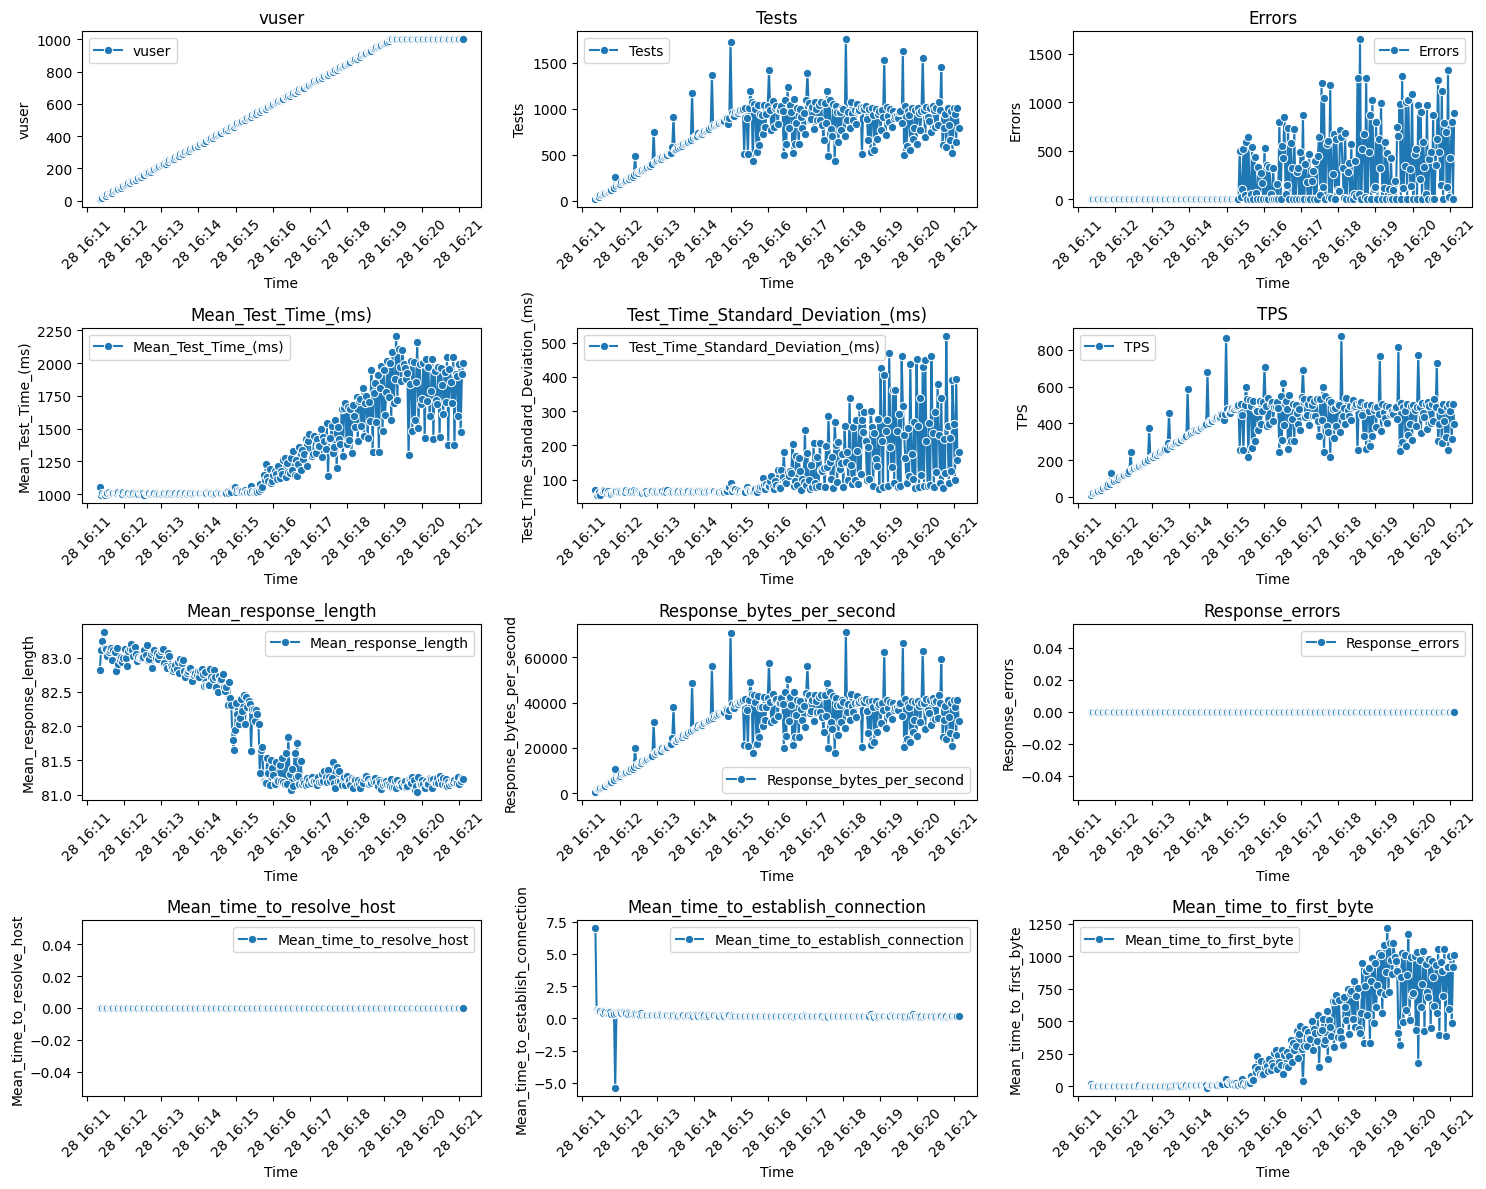

In [40]:
# 플롯 크기 설정
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
axes = axes.flatten()  # 2D 배열을 1D로 변환하여 인덱싱 쉽게 하기

# 시각화할 컬럼 리스트
columns = df.columns[1:]  # DateTime 제외

# 각 컬럼별 차트 그리기
for i, col in enumerate(columns):
    sns.lineplot(ax=axes[i], x=df['DateTime'], y=df[col], marker='o', label=col)
    axes[i].set_title(col)
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis='x', rotation=45)

# 레이아웃 조정
plt.tight_layout()
plt.show()

# ✅ 성능 지표 설명

| 컬럼명 | 약어 | 설명 |
|--------|------|------|
| **DateTime** | - | 테스트 수행 시각 (UTC 기준으로 기록되며, KST로 변환 가능) |
| **vuser** | Virtual Users | 동시 가상 사용자의 수 (부하 테스트에서 한 번에 실행되는 사용자 수) |
| **Tests** | Total Tests | 수행된 전체 테스트 요청 수 |
| **Errors** | Error Count | 테스트 중 발생한 오류 개수 |
| **Mean_Test_Time_(ms)** | Mean Response Time | 평균 응답 시간 (밀리초 단위, 낮을수록 좋음) |
| **Test_Time_Standard_Deviation_(ms)** | Response Time Std Dev | 응답 시간의 표준 편차 (값이 클수록 응답 시간이 불안정함) |
| **TPS** | Transactions Per Second | 초당 수행된 트랜잭션 수 (처리량, 높을수록 좋음) |
| **Mean_response_length** | Avg Response Size | 평균 응답 데이터 크기 (바이트 단위) |
| **Response_bytes_per_second** | Response Throughput | 초당 응답 데이터 전송량 (바이트/초, 높을수록 좋음) |
| **Response_errors** | Response Error Count | 응답 중 발생한 오류 개수 |
| **Mean_time_to_resolve_host** | DNS Resolution Time | 평균 호스트 이름(DNS) 해결 시간 (ms, 낮을수록 좋음) |
| **Mean_time_to_establish_connection** | Connection Time | 평균 TCP 연결 수립 시간 (ms, 낮을수록 좋음) |
| **Mean_time_to_first_byte** | TTFB (Time To First Byte) | 서버에서 첫 번째 바이트를 받기까지 걸리는 시간 (ms, 낮을수록 좋음) |

---

### 📌 해석 예시
- `vuser` 값이 높아질수록 `TPS`(처리량)도 증가하는지 확인해야 함.
- `Mean_Test_Time_(ms)`와 `Test_Time_Standard_Deviation_(ms)`이 높으면 성능이 불안정할 가능성이 있음.
- `Response_errors`가 많으면 시스템 장애나 네트워크 이슈를 의심해야 함.
- `Mean_time_to_resolve_host`, `Mean_time_to_establish_connection`, `Mean_time_to_first_byte` 값이 클 경우, DNS 문제, 네트워크 병목, 서버 응답 지연 등의 원인을 분석해야 함.


In [41]:
# DateTime을 인덱스로 설정
df.set_index('DateTime', inplace=True)

# 10초 단위로 리샘플링하고 평균 계산
df_resampled = df.resample('10s').mean()

# 결과 출력
# print(df_resampled)

# 인덱스를 다시 컬럼으로 변환 (선택 사항)
df_resampled.reset_index(inplace=True)

# 최종 결과 출력
df_resampled.head(10)

,DateTime,vuser,Tests,Errors,Mean_Test_Time_(ms),Test_Time_Standard_Deviation_(ms),TPS,Mean_response_length,Response_bytes_per_second,Response_errors,Mean_time_to_resolve_host,Mean_time_to_establish_connection,Mean_time_to_first_byte
0,2025-02-28 16:11:20+09:00,21.4,40.6,0.0,1008.8180,61.2742,20.3,83.1368,1688.4,0.0,0.0,1.8794,7.3854
1,2025-02-28 16:11:30+09:00,41.8,77.4,0.0,1008.0502,66.7828,38.7,83.0932,3215.8,0.0,0.0,0.4696,4.1562
2,2025-02-28 16:11:40+09:00,61.6,116.4,0.0,1008.0578,61.1478,58.2,83.0164,4831.7,0.0,0.0,0.4424,4.2878
3,2025-02-28 16:11:50+09:00,82.4,181.6,0.0,1009.2640,65.3298,90.8,82.9598,7532.9,0.0,0.0,-0.7274,3.3436
4,2025-02-28 16:12:00+09:00,104.2,203.2,0.0,1004.6848,64.4890,101.6,83.0414,8437.1,0.0,0.0,0.4526,4.4556
5,2025-02-28 16:12:10+09:00,124.6,241.8,0.0,1005.5198,66.7884,120.9,83.1064,10047.4,0.0,0.0,0.3918,4.3786
6,2025-02-28 16:12:20+09:00,147.6,325.6,0.0,1003.6506,66.3076,162.8,82.9882,13510.5,0.0,0.0,0.3486,4.5436
7,2025-02-28 16:12:30+09:00,167.0,328.4,0.0,1003.5696,61.9140,164.2,83.0602,13638.5,0.0,0.0,0.3020,4.5904
8,2025-02-28 16:12:40+09:00,187.4,366.4,0.0,1005.1044,64.5196,183.2,83.0130,15208.2,0.0,0.0,0.2672,4.2542
9,2025-02-28 16:12:50+09:00,208.8,480.6,0.0,1002.9056,66.6134,240.3,83.0336,19951.5,0.0,0.0,0.2384,3.8294


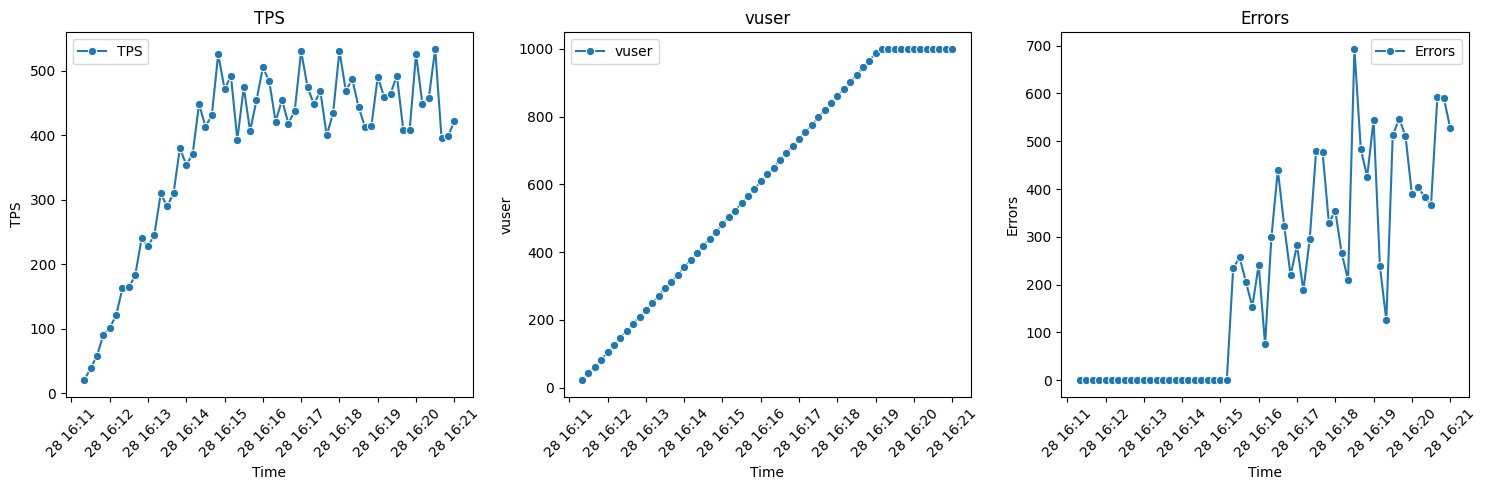

In [50]:
def show_chart(df, nrows=1, ncols=3):
    # 플롯 크기 설정
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5))
    axes = axes.flatten()  # 2D 배열을 1D로 변환하여 인덱싱 쉽게 하기
    
    # 시각화할 컬럼 리스트
    columns = df.columns[1:]  # DateTime 제외
    
    # 각 컬럼별 차트 그리기
    for i, col in enumerate(columns):
        sns.lineplot(ax=axes[i], x=df['DateTime'], y=df[col], marker='o', label=col)
        axes[i].set_title(col)
        axes[i].set_xlabel('Time')
        axes[i].set_ylabel(col)
        axes[i].tick_params(axis='x', rotation=45)
    
    # 레이아웃 조정
    plt.tight_layout()
    plt.show()

show_chart(df_resampled[['DateTime', 'TPS','vuser','Errors']])

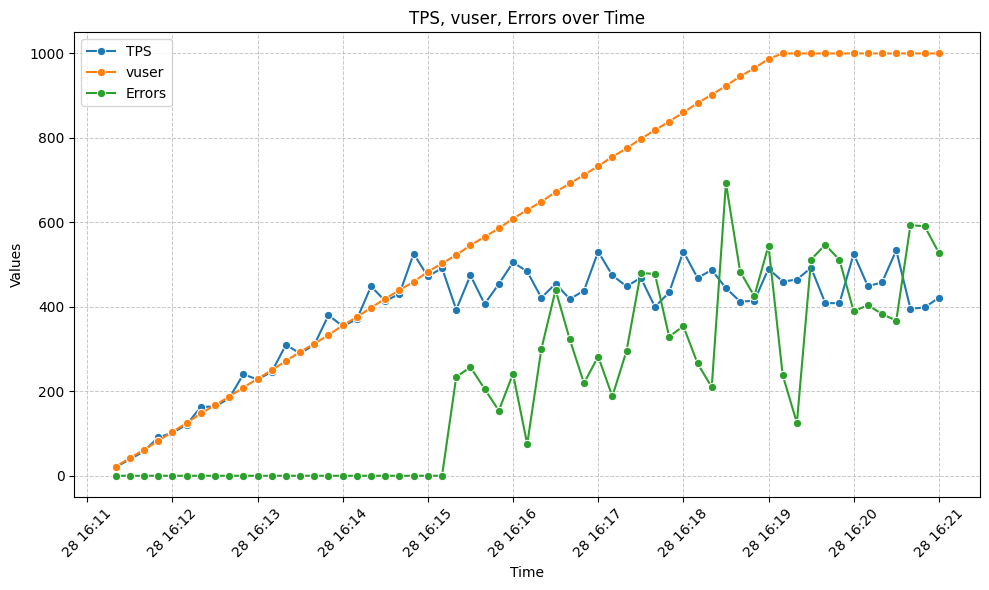

In [54]:
def show_single_chart(df):
    # 플롯 크기 설정
    plt.figure(figsize=(10, 6))

    # 각 컬럼을 하나의 차트에 그리기
    columns = df.columns[1:]  # DateTime 제외 ('TPS', 'vuser', 'Errors')

    for col in columns:
        sns.lineplot(x=df['DateTime'], y=df[col], marker='o', label=col)

    # 차트 제목 및 라벨 설정
    plt.title('TPS, vuser, Errors over Time')
    plt.xlabel('Time')
    plt.ylabel('Values')
    plt.xticks(rotation=45)

    # 세로 및 가로 보조선 추가
    plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

    # 범례 추가
    plt.legend()

    # 레이아웃 조정
    plt.tight_layout()
    plt.show()

# 함수 호출
show_single_chart(df_resampled[['DateTime', 'TPS', 'vuser', 'Errors']])

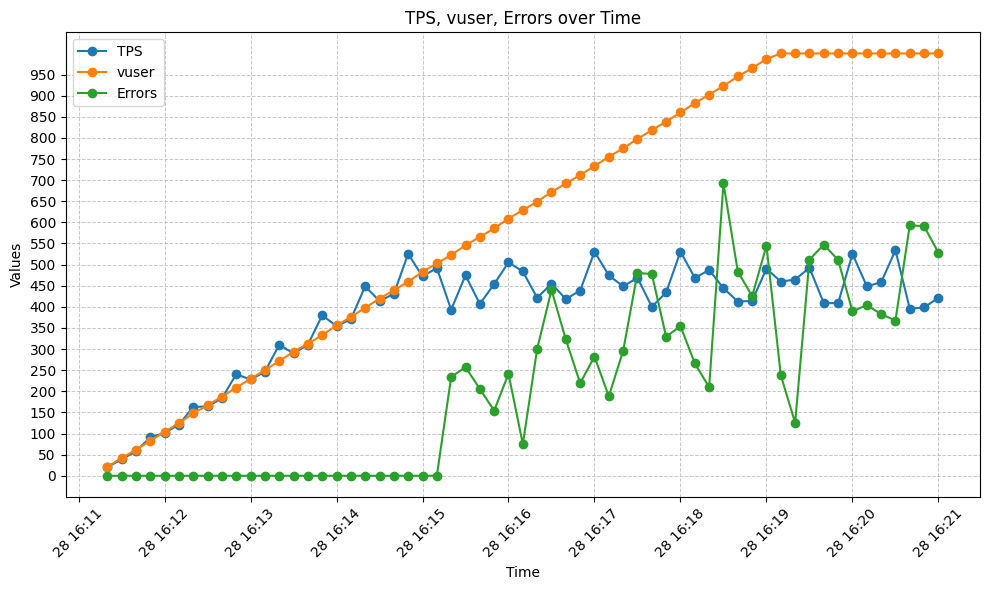

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

def show_single_chart(df):
    # 플롯 크기 설정
    fig, ax = plt.subplots(figsize=(10, 6))

    # 각 컬럼을 하나의 차트에 그리기
    columns = df.columns[1:]  # DateTime 제외 ('TPS', 'vuser', 'Errors')

    # 컬럼별로 선 그래프 그리기
    for col in columns:
        ax.plot(df['DateTime'], df[col], marker='o', label=col)

    # 차트 제목 및 라벨 설정
    ax.set_title('TPS, vuser, Errors over Time')
    ax.set_xlabel('Time')
    ax.set_ylabel('Values')
    ax.tick_params(axis='x', rotation=45)

    # Y축 눈금 간격을 10으로 설정
    max_y = int(df[columns].max().max())  # Y축 최대값 계산
    min_y = int(df[columns].min().min())  # Y축 최소값 계산
    ax.set_yticks(range(min_y - (min_y % 50), max_y + (50 - max_y % 50) if max_y % 50 != 0 else max_y, 50))

    # 세로 및 가로 보조선 추가
    ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

    # 범례 추가
    ax.legend()

    # 레이아웃 조정
    plt.tight_layout()
    plt.show()

# 함수 호출
show_single_chart(df_resampled[['DateTime', 'TPS', 'vuser', 'Errors']])

In [57]:
# pdm add pyarrow
df_resampled[['DateTime', 'TPS', 'vuser', 'Errors']].to_parquet('01_numpy_ng.parquet')